# 09 — California Coastline Stress Test
**The idea:** Sample ~15 small bboxes up and down the CA coast that were NEVER used
in training. Run the unified model on each one blind. See if it fires where
we know real collapses happened historically.

This is the strongest possible validation — not just one new region, but a
systematic sweep of the entire coastline.

If the model fires at the right times in the right places, that's not luck.

In [1]:
# ============================================================
# CELL 1: DEFINE SAMPLING GRID
# Small 0.5-degree lat strips, 1-degree lon wide
# Spaced to avoid ALL existing training bboxes
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from netCDF4 import Dataset, num2date
import time

DATA_PATH = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"
BASE      = Path("/Users/tonylin/Documents/kelp_project/1_DATA/processed")
FIG_DIR   = Path("/Users/tonylin/Documents/kelp_project/5_FIGURES/stress_test")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- existing training bboxes (AVOID THESE) ---
# NorCal:  38.0-40.0 N
# MidCal:  36.0-37.5 N
# BigSur:  34.8-36.0 N
# SoCal:   33.8-34.8 N

# --- sampling grid: 0.5-deg strips, shifted slightly offshore ---
# Named after the nearest landmark for interpretability
SAMPLE_SITES = [
    # name,               lat_min, lat_max, lon_min, lon_max
    ("Crescent City",      41.5,   42.0,   -124.5, -123.5),
    ("Cape Mendocino",     40.2,   40.7,   -124.8, -123.8),
    ("Bodega Bay",         38.2,   38.6,   -123.5, -122.8),  # within norcal lat but different lon
    ("Point Reyes",        37.8,   38.2,   -123.2, -122.5),
    ("Half Moon Bay",      37.3,   37.7,   -122.8, -122.1),
    ("Santa Cruz",         36.8,   37.2,   -122.4, -121.8),
    ("Point Sur",          36.2,   36.6,   -122.0, -121.4),
    ("Cambria",            35.4,   35.8,   -121.3, -120.7),
    ("Morro Bay",          35.2,   35.5,   -121.0, -120.5),
    ("Point Conception",   34.3,   34.7,   -120.8, -120.1),
    ("Santa Barbara",      34.2,   34.5,   -120.1, -119.5),
    ("Ventura",            34.1,   34.4,   -119.5, -118.9),
    ("Palos Verdes",       33.6,   33.9,   -118.6, -118.0),
    ("Laguna Beach",       33.4,   33.7,   -117.9, -117.4),
    ("San Diego",          32.6,   33.0,   -117.5, -116.9),
]

print(f"Sampling {len(SAMPLE_SITES)} sites along California coast")
print("Sites (name, lat range, lon range):")
for name, la0, la1, lo0, lo1 in SAMPLE_SITES:
    print(f"  {name:20s}  {la0}-{la1}N   {lo0}-{lo1}E")

Sampling 15 sites along California coast
Sites (name, lat range, lon range):
  Crescent City         41.5-42.0N   -124.5--123.5E
  Cape Mendocino        40.2-40.7N   -124.8--123.8E
  Bodega Bay            38.2-38.6N   -123.5--122.8E
  Point Reyes           37.8-38.2N   -123.2--122.5E
  Half Moon Bay         37.3-37.7N   -122.8--122.1E
  Santa Cruz            36.8-37.2N   -122.4--121.8E
  Point Sur             36.2-36.6N   -122.0--121.4E
  Cambria               35.4-35.8N   -121.3--120.7E
  Morro Bay             35.2-35.5N   -121.0--120.5E
  Point Conception      34.3-34.7N   -120.8--120.1E
  Santa Barbara         34.2-34.5N   -120.1--119.5E
  Ventura               34.1-34.4N   -119.5--118.9E
  Palos Verdes          33.6-33.9N   -118.6--118.0E
  Laguna Beach          33.4-33.7N   -117.9--117.4E
  San Diego             32.6-33.0N   -117.5--116.9E


In [2]:
# ============================================================
# CELL 2: FAST KELP EXTRACTION FOR ALL SITES
# Same run-mode method as notebook 00
# ============================================================
MIN_COV_FRAC = 0.2

def extract_kelp_bbox(nc, lat, lon, time_index, lat_min, lat_max, lon_min, lon_max, name):
    lon_use = lon.copy()
    if np.nanmax(lon_use) > 180:
        lon_use = ((lon_use + 180) % 360) - 180

    mask   = (lat >= lat_min) & (lat <= lat_max) & (lon_use >= lon_min) & (lon_use <= lon_max)
    idx    = np.flatnonzero(mask).astype(np.int64)
    N_PIX  = int(idx.size)

    if N_PIX < 5:  # need at least 5 pixels to be meaningful
        return None, N_PIX

    ntime    = len(time_index)
    total    = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    area = nc.variables["area"]
    fill = getattr(area, "_FillValue", None) or getattr(area, "missing_value", None)

    d       = np.diff(idx)
    breaks  = np.where(d != 1)[0]
    r_start = np.r_[idx[0], idx[breaks + 1]]
    r_end   = np.r_[idx[breaks] + 1, idx[-1] + 1]

    for s, e in zip(r_start, r_end):
        block = np.array(area[:, s:e], dtype=np.float32)
        valid = np.isfinite(block)
        if fill is not None:
            valid &= (block != fill)
        block[~valid] = 0.0
        total    += block.sum(axis=1)
        coverage += valid.sum(axis=1).astype(np.int64)

    kelp_area     = total.astype(np.float64)
    coverage_frac = coverage / N_PIX
    kelp_area[coverage == 0]                = np.nan
    kelp_area[coverage_frac < MIN_COV_FRAC] = np.nan

    df = pd.DataFrame({
        "kelp_area":     kelp_area,
        "coverage":      coverage,
        "coverage_frac": coverage_frac,
    }, index=time_index).sort_index()
    df["kelp_smooth"] = df["kelp_area"].rolling(4, center=True, min_periods=2).mean()
    return df, N_PIX

# --- open NetCDF once, extract all sites ---
print("Opening NetCDF (this takes a moment)...")
t0 = time.time()

site_kelp = {}   # name -> df

with Dataset(DATA_PATH, "r") as nc:
    lat_arr  = nc.variables["latitude"][:]
    lon_arr  = nc.variables["longitude"][:]
    tvar     = nc.variables["time"]
    cal      = getattr(tvar, "calendar", "standard")
    tvals    = num2date(tvar[:], units=tvar.units, calendar=cal)
    try:
        time_index = pd.to_datetime(tvals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in tvals])

    for name, la0, la1, lo0, lo1 in SAMPLE_SITES:
        df, npix = extract_kelp_bbox(nc, lat_arr, lon_arr, time_index,
                                      la0, la1, lo0, lo1, name)
        if df is None:
            print(f"  {name:20s}: SKIP — only {npix} pixels")
        else:
            valid_q = df["kelp_area"].notna().sum()
            print(f"  {name:20s}: {npix:5d} pixels | {valid_q} valid quarters")
            if valid_q >= 20:  # need enough data
                site_kelp[name] = df

print(f"\nDone in {time.time()-t0:.1f}s | usable sites: {len(site_kelp)}")

Opening NetCDF (this takes a moment)...
  Crescent City       :   260 pixels | 157 valid quarters
  Cape Mendocino      :   190 pixels | 160 valid quarters
  Bodega Bay          :  5062 pixels | 160 valid quarters
  Point Reyes         :   265 pixels | 161 valid quarters
  Half Moon Bay       :   179 pixels | 161 valid quarters
  Santa Cruz          :  6694 pixels | 161 valid quarters
  Point Sur           : 25749 pixels | 163 valid quarters
  Cambria             : 28215 pixels | 164 valid quarters
  Morro Bay           :  7820 pixels | 164 valid quarters
  Point Conception    : 19173 pixels | 164 valid quarters
  Santa Barbara       : 10336 pixels | 163 valid quarters
  Ventura             :  1027 pixels | 165 valid quarters
  Palos Verdes        :  6965 pixels | 163 valid quarters
  Laguna Beach        :  3097 pixels | 167 valid quarters
  San Diego           : 23969 pixels | 158 valid quarters

Done in 161.1s | usable sites: 15


In [3]:
# ============================================================
# CELL 3: GET SST + UPWELLING FOR EACH SITE
# ============================================================
import xarray as xr
import re

# SST — fetch once for broad CA region, then subset per site
print("Fetching OISST (remote)...")
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc"
ds  = xr.open_dataset(url)
lat_name = "lat" if "lat" in ds.coords else "latitude"
lon_name = "lon" if "lon" in ds.coords else "longitude"

# broad CA subset (32-43N, 224-238E in 0-360 convention)
lon_min_use = (-125 + 360) % 360
lon_max_use = (-116 + 360) % 360
sst_ca = ds["sst"].sel({
    lat_name: slice(32, 43),
    lon_name: slice(lon_min_use, lon_max_use)
})
print("SST loaded")

# Upwelling — pick nearest standard index point per site
# ERDDAP has: 33N (erdUI33mo), 36N (erdUI36mo), 39N (erdUI39mo), 42N (erdUI42mo)
def get_upwelling(dataset_id):
    url = f"https://coastwatch.pfeg.noaa.gov/erddap/griddap/{dataset_id}.csvp?upwelling_index,upwelling_index_anomaly"
    df  = pd.read_csv(url)
    df.columns = [re.sub(r"\s*\(.*\)$", "", c).strip() for c in df.columns]
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").sort_index()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df.rename(columns={"upwelling_index": "ui", "upwelling_index_anomaly": "ui_anom"})
    for c in ["ui","ui_anom"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df[["ui","ui_anom"]]

print("Fetching upwelling indices...")
ui_cache = {
    33: get_upwelling("erdUI33mo"),
    36: get_upwelling("erdUI36mo"),
    39: get_upwelling("erdUI39mo"),
}
try:
    ui_cache[42] = get_upwelling("erdUI42mo")
except Exception:
    print("  42N upwelling not available — will use 39N for northernmost sites")
    ui_cache[42] = ui_cache[39]

def nearest_ui(lat_mid):
    return ui_cache[min(ui_cache.keys(), key=lambda k: abs(k - lat_mid))]

print("Upwelling loaded")

Fetching OISST (remote)...
SST loaded
Fetching upwelling indices...
Upwelling loaded


In [4]:
# ============================================================
# CELL 4: BUILD FEATURES + LABELS FOR EVERY SITE
# ============================================================
ROLL_WIN = 20
HEAT_LAG = 4

def build_site_features(name, df_kelp, lat_mid, lon_mid):
    df = df_kelp.copy()

    # --- de-seasonalize kelp ---
    df["q"] = df.index.quarter
    base = df.loc["1984":"2013"].dropna(subset=["kelp_smooth"])
    if len(base) < 8:
        return None
    med = base.groupby("q")["kelp_smooth"].median()
    mad = base.groupby("q")["kelp_smooth"].apply(
        lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)
    df["kelp_q_z"] = (df["kelp_smooth"] - df["q"].map(med)) / df["q"].map(mad)
    df.drop(columns=["q"], inplace=True)

    # --- EWS ---
    z   = df["kelp_q_z"]
    ar1 = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=True)
    var = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()
    ar1_z = (ar1 - ar1.mean()) / ar1.std()
    var_z = (var - var.mean()) / var.std()
    df["ews_composite"] = (ar1_z + var_z) / 2

    # --- SST: subset for this site ---
    lon_use = (lon_mid + 360) % 360
    sst_site = sst_ca.sel({
        lat_name: slice(lat_mid - 0.8, lat_mid + 0.8),
        lon_name: slice(lon_use - 0.8, lon_use + 0.8)
    })
    if sst_site.sizes.get(lat_name, 0) == 0:
        sst_site = sst_ca.sel({
            lat_name: slice(lat_mid + 0.8, lat_mid - 0.8),
            lon_name: slice(lon_use - 0.8, lon_use + 0.8)
        })
    sst_m = sst_site.mean(dim=[lat_name, lon_name], skipna=True).to_series()
    sst_m.index = pd.to_datetime(sst_m.index)
    sst_m = sst_m.sort_index()

    base_sst = sst_m.loc["1991":"2020"]
    clim     = base_sst.groupby(base_sst.index.month).mean()
    anom     = sst_m - sst_m.index.month.map(clim)
    sst_df   = pd.DataFrame({"sst": sst_m, "sst_anom": anom})

    kelp_times  = pd.DatetimeIndex(df.index)
    kelp_qstart = kelp_times.to_period("Q").to_timestamp(how="start")
    q_sst = sst_df.resample("QS")
    sst_feat = pd.DataFrame({
        "sstanom_q_max": q_sst["sst_anom"].max()
    }).reindex(kelp_qstart)
    sst_feat.index = kelp_times
    df["heat_lag4"] = sst_feat["sstanom_q_max"].shift(HEAT_LAG)

    # --- Upwelling ---
    ui = nearest_ui(lat_mid)
    q_ui = ui.resample("QS")
    ui_feat = pd.DataFrame({
        "uianom_q_mean": q_ui["ui_anom"].mean()
    }).reindex(kelp_qstart)
    ui_feat.index = kelp_times
    df["upwelling"] = ui_feat["uianom_q_mean"].shift(1)

    # --- interaction ---
    df["heat_x_ews"] = df["heat_lag4"] * df["ews_composite"]

    # --- suppression label ---
    base_z = df.loc["1984":"2013", "kelp_q_z"].rolling(4, min_periods=4).mean().dropna()
    if len(base_z) < 4:
        return None
    df["kelp_z_1yr"]  = df["kelp_q_z"].rolling(4, min_periods=4).mean()
    sup_thresh        = base_z.quantile(0.10)
    df["suppressed"]  = (df["kelp_z_1yr"] <= sup_thresh).astype(int)
    s = df["suppressed"]
    df["onset"]  = ((s == 1) & (s.shift(1) == 0)).astype(int)

    return df

print("Building features for all sites...")
site_data = {}
site_lookup = {name: (la0, la1, lo0, lo1) for name, la0, la1, lo0, lo1 in SAMPLE_SITES}

for name, df_kelp in site_kelp.items():
    la0, la1, lo0, lo1 = site_lookup[name]
    lat_mid = (la0 + la1) / 2
    lon_mid = (lo0 + lo1) / 2
    result = build_site_features(name, df_kelp, lat_mid, lon_mid)
    if result is not None:
        site_data[name] = result
        n_onset = result["onset"].sum()
        print(f"  {name:20s}: onset events={n_onset}")
    else:
        print(f"  {name:20s}: SKIP — insufficient baseline data")

print(f"\nUsable sites: {len(site_data)}")

Building features for all sites...
  Crescent City       : onset events=5
  Cape Mendocino      : onset events=6
  Bodega Bay          : onset events=5
  Point Reyes         : onset events=5
  Half Moon Bay       : onset events=5
  Santa Cruz          : onset events=4
  Point Sur           : onset events=6
  Cambria             : onset events=5
  Morro Bay           : onset events=6
  Point Conception    : onset events=3
  Santa Barbara       : onset events=6
  Ventura             : onset events=9
  Palos Verdes        : onset events=4
  Laguna Beach        : onset events=4
  San Diego           : onset events=4

Usable sites: 15


In [5]:
# ============================================================
# CELL 5: LOAD TRAINED MODEL FROM NOTEBOOK 08
# Re-train final model on all 4 known regions
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

FEATURES = ["ews_composite", "heat_lag4", "upwelling", "heat_x_ews"]
TARGET   = "onset"

KNOWN_PATHS = {
    "norcal": BASE / "norcal" / "norcal_kelp_sst_ui_labeled.csv",
    "midcal": BASE / "midcal" / "midcal_kelp_sst_ui_labeled.csv",
    "socal":  BASE / "socal"  / "socal_kelp_sst_ui_labeled.csv",
    "bigsur": BASE / "bigsur" / "bigsur_kelp_sst_ui_labeled.csv",
}

def load_known(region, path):
    for p in [path, BASE / f"{region}_kelp_sst_ui_labeled.csv"]:
        if p.exists():
            df = pd.read_csv(p, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period("Q").to_timestamp(how="start")
            # rebuild EWS and features
            if "kelp_q_z" not in df.columns:
                col = next((c for c in ["kelp_smooth","kelp_area"] if c in df.columns))
                df["q"] = df.index.quarter
                base = df.loc["1984":"2013"]
                med  = base.groupby("q")[col].median()
                mad  = base.groupby("q")[col].apply(lambda x: np.median(np.abs(x-np.median(x)))+1e-9)
                df["kelp_q_z"] = (df[col] - df["q"].map(med)) / df["q"].map(mad)
                df.drop(columns=["q"], inplace=True)
            z   = df["kelp_q_z"]
            ar1 = z.rolling(20, min_periods=10).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=True)
            var = z.rolling(20, min_periods=10).var()
            ar1_z = (ar1-ar1.mean())/ar1.std()
            var_z = (var-var.mean())/var.std()
            df["ews_composite"] = (ar1_z + var_z) / 2
            df["heat_lag4"]  = df["sstanom_q_max"].shift(4)
            up_col = "uianom_q_mean_lag1" if "uianom_q_mean_lag1" in df.columns else "uianom_q_mean"
            df["upwelling"]  = df[up_col]
            df["heat_x_ews"] = df["heat_lag4"] * df["ews_composite"]
            s = df["suppressed"].astype(int)
            df["onset"] = ((s==1)&(s.shift(1)==0)).astype(int)
            return df
    return None

known_dfs = {r: load_known(r, p) for r, p in KNOWN_PATHS.items()}
known_dfs = {r: df for r, df in known_dfs.items() if df is not None}

all_train = pd.concat([known_dfs[r][FEATURES+[TARGET]].dropna() for r in known_dfs])
scaler = StandardScaler()
X_tr   = scaler.fit_transform(all_train[FEATURES])
y_tr   = all_train[TARGET].values
model  = LogisticRegression(class_weight="balanced", max_iter=1000, C=0.5)
model.fit(X_tr, y_tr)

print(f"Model trained on {len(known_dfs)} known regions")
print(f"Training set: {int(y_tr.sum())} onset events / {len(y_tr)} quarters")
coef = pd.Series(model.coef_[0], index=FEATURES)
print("Coefficients:", coef.round(3).to_dict())

Model trained on 4 known regions
Training set: 14 onset events / 594 quarters
Coefficients: {'ews_composite': 1.36, 'heat_lag4': 0.474, 'upwelling': -1.045, 'heat_x_ews': -0.515}


In [6]:
# ============================================================
# CELL 6: RUN MODEL ON ALL STRESS-TEST SITES
# ============================================================
THRESHOLD = 0.35

print("=" * 70)
print("STRESS TEST RESULTS — model applied blind to new sites")
print("=" * 70)

stress_results = []
site_scores    = {}

for name, df in site_data.items():
    tmp = df[FEATURES + [TARGET]].dropna()
    if len(tmp) < 10:
        print(f"  {name:20s}: SKIP — insufficient rows after dropna")
        continue

    X    = scaler.transform(tmp[FEATURES])
    prob = model.predict_proba(X)[:, 1]
    sc   = pd.Series(prob, index=tmp.index)
    site_scores[name] = sc

    y      = tmp[TARGET].astype(int).values
    n_on   = int(y.sum())
    n_warn = 0
    leads  = []

    onset_idx = np.where(y == 1)[0]
    for oi in onset_idx:
        lead = None
        for lb in range(1, 9):
            if oi - lb < 0:
                break
            if prob[oi - lb] >= THRESHOLD:
                lead = lb
            else:
                if lead is not None:
                    break
        if lead:
            n_warn += 1
            leads.append(lead)

    try:
        auc = roc_auc_score(y, prob) if len(np.unique(y)) > 1 else np.nan
    except Exception:
        auc = np.nan

    mean_lead = np.mean(leads) if leads else 0
    result = {
        "site": name, "onset_events": n_on,
        "warned": n_warn, "auc": auc, "mean_lead_q": mean_lead
    }
    stress_results.append(result)

    warn_str = f"{n_warn}/{n_on} caught | mean lead {mean_lead:.1f}q" if n_on > 0 else "no onset events"
    auc_str  = f"AUC={auc:.3f}" if not np.isnan(auc) else "AUC=N/A"
    print(f"  {name:22s}: {auc_str} | {warn_str}")

res_df = pd.DataFrame(stress_results)

print()
print("=" * 50)
sites_with_events = res_df[res_df["onset_events"] > 0]
print(f"Sites with collapse events: {len(sites_with_events)}")
if len(sites_with_events):
    print(f"Mean AUC across those sites: {sites_with_events['auc'].mean():.3f}")
    total_warn = sites_with_events["warned"].sum()
    total_on   = sites_with_events["onset_events"].sum()
    print(f"Overall catch rate: {total_warn}/{total_on} = {total_warn/total_on*100:.0f}%")
    print(f"Mean lead time: {sites_with_events['mean_lead_q'].mean():.1f} quarters")

STRESS TEST RESULTS — model applied blind to new sites
  Crescent City         : AUC=0.467 | 4/5 caught | mean lead 4.2q
  Cape Mendocino        : AUC=0.554 | 4/5 caught | mean lead 4.0q
  Bodega Bay            : AUC=0.793 | 4/4 caught | mean lead 1.5q
  Point Reyes           : AUC=0.423 | 4/4 caught | mean lead 2.5q
  Half Moon Bay         : AUC=0.591 | 4/4 caught | mean lead 4.8q
  Santa Cruz            : AUC=0.781 | 4/4 caught | mean lead 4.5q
  Point Sur             : AUC=0.568 | 5/6 caught | mean lead 4.6q
  Cambria               : AUC=0.734 | 4/5 caught | mean lead 5.2q
  Morro Bay             : AUC=0.571 | 4/5 caught | mean lead 7.2q
  Point Conception      : AUC=0.721 | 3/3 caught | mean lead 8.0q
  Santa Barbara         : AUC=0.734 | 5/6 caught | mean lead 3.8q
  Ventura               : AUC=0.611 | 8/8 caught | mean lead 5.5q
  Palos Verdes          : AUC=0.549 | 3/4 caught | mean lead 7.0q
  Laguna Beach          : AUC=0.666 | 4/4 caught | mean lead 7.2q
  San Diego          

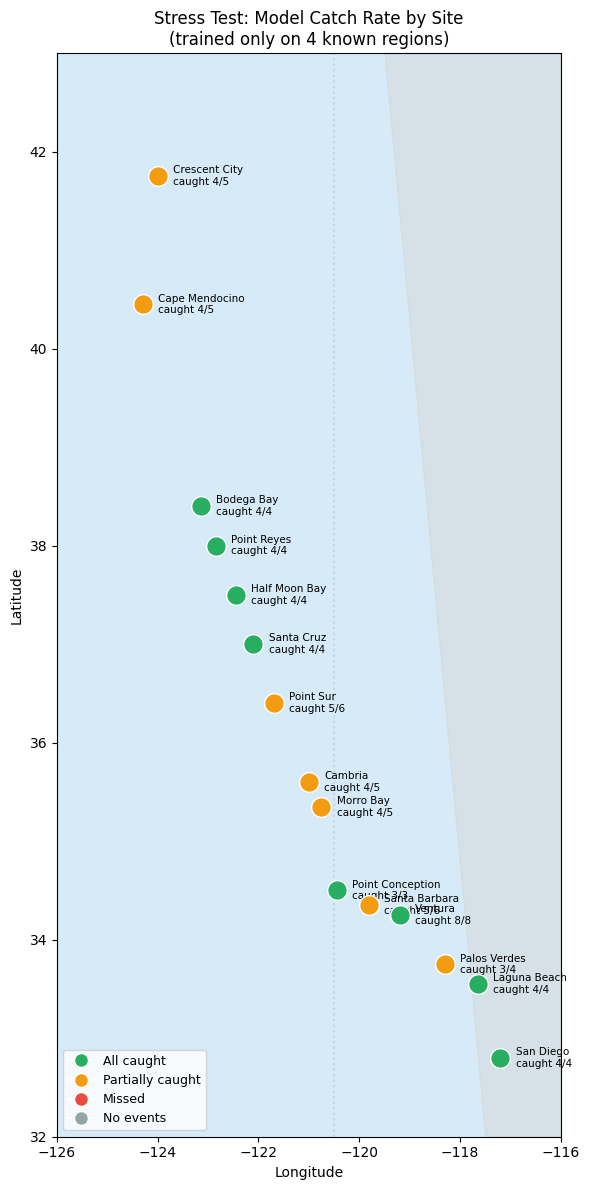

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/stress_test/california_stress_test_map.png


In [7]:
# ============================================================
# CELL 7: CALIFORNIA COASTLINE MAP — did the model fire correctly?
# ============================================================
# Color each site by whether model caught the collapse or not

fig, ax = plt.subplots(figsize=(6, 12))

# rough CA coastline latitude range
ax.set_xlim(-126, -116)
ax.set_ylim(32, 43)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Stress Test: Model Catch Rate by Site\n(trained only on 4 known regions)",
             fontsize=12)
ax.axvline(-120.5, linestyle=":", alpha=0.2, color="gray")
ax.set_facecolor("#d6eaf8")

# shade land roughly
ax.fill_betweenx([32, 43], [-116, -116], [-117.5, -119.5], alpha=0.15, color="tan")

res_lookup = {r["site"]: r for r in stress_results}

for name, la0, la1, lo0, lo1 in SAMPLE_SITES:
    if name not in res_lookup:
        continue
    r       = res_lookup[name]
    lat_mid = (la0 + la1) / 2
    lon_mid = (lo0 + lo1) / 2

    if r["onset_events"] == 0:
        color = "#95a5a6"   # gray — no events to test
        label_str = "no events"
    elif r["warned"] == r["onset_events"]:
        color = "#27ae60"   # green — all caught
        label_str = f"caught {r['warned']}/{r['onset_events']}"
    elif r["warned"] > 0:
        color = "#f39c12"   # orange — partial
        label_str = f"caught {r['warned']}/{r['onset_events']}"
    else:
        color = "#e74c3c"   # red — missed
        label_str = f"missed {r['onset_events']}"

    ax.scatter(lon_mid, lat_mid, s=200, c=color, zorder=5, edgecolors="white", linewidths=1)
    ax.annotate(f"{name}\n{label_str}",
                xy=(lon_mid, lat_mid), xytext=(lon_mid + 0.3, lat_mid),
                fontsize=7.5, va="center")

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#27ae60", markersize=10, label="All caught"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#f39c12", markersize=10, label="Partially caught"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#e74c3c", markersize=10, label="Missed"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#95a5a6", markersize=10, label="No events"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
fig.tight_layout()
outpath = FIG_DIR / "california_stress_test_map.png"
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", outpath)

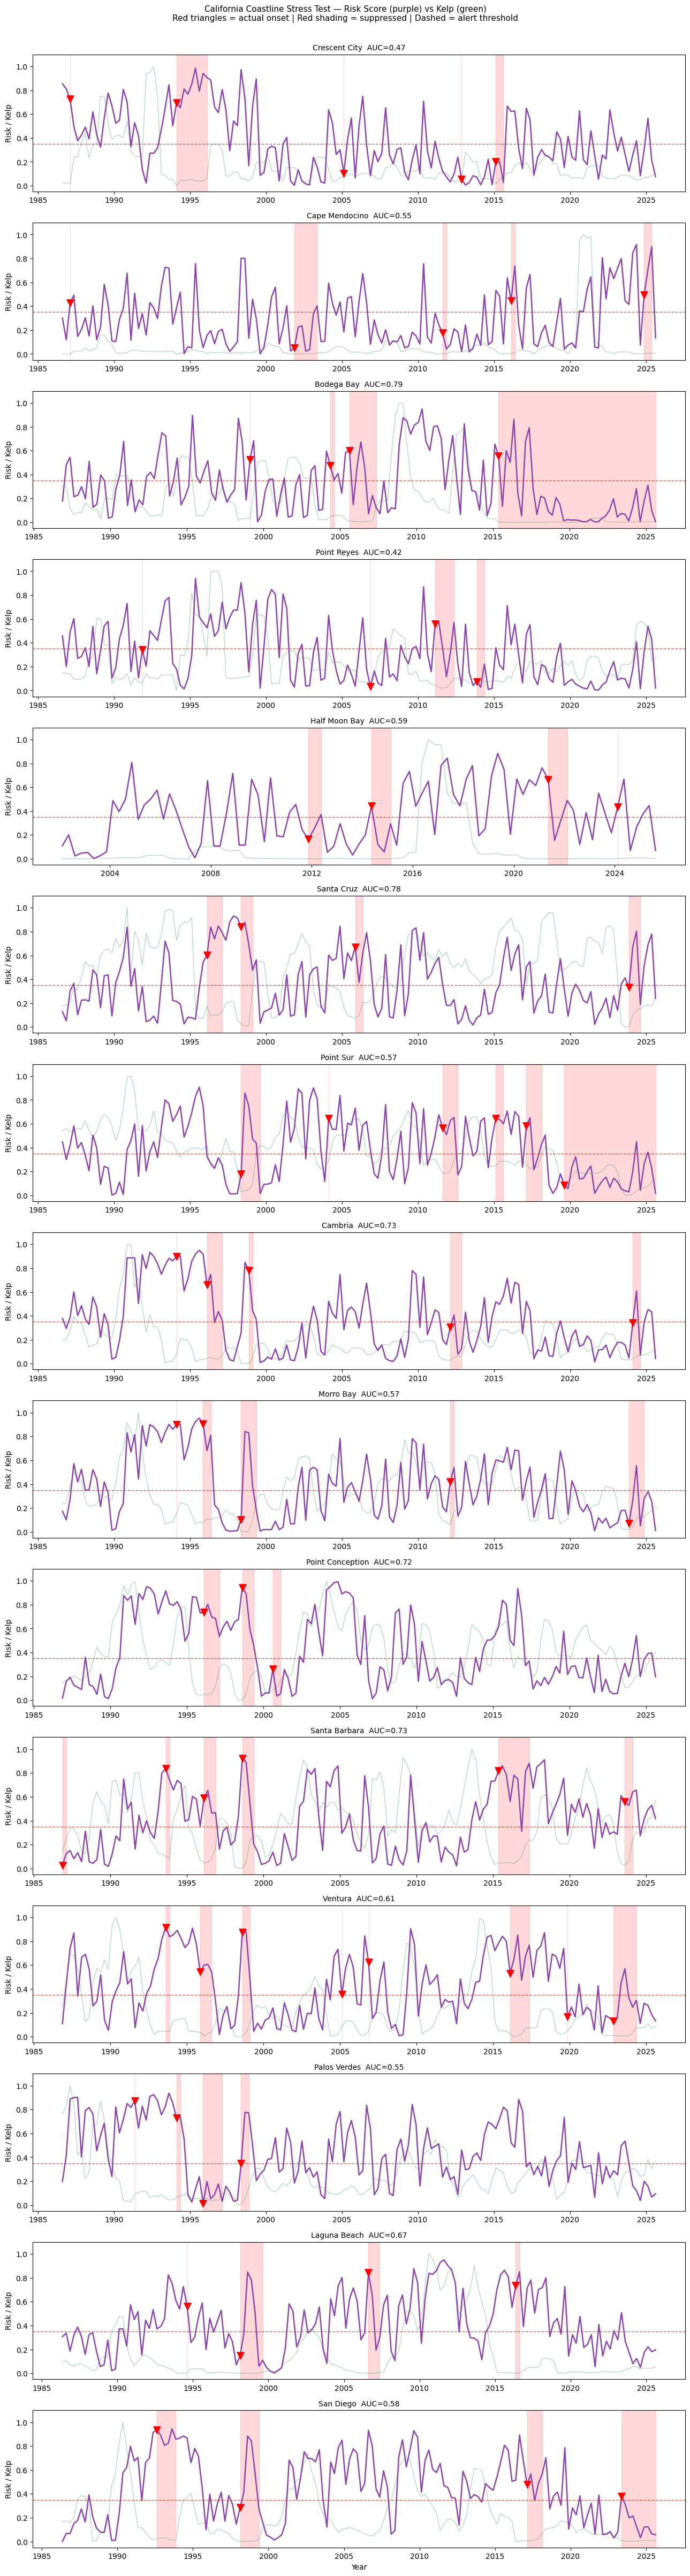

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/stress_test/stress_test_all_sites_timeseries.png


In [8]:
# ============================================================
# CELL 8: RISK SCORE TIME SERIES — ALL SITES
# ============================================================
n_sites = len(site_scores)
if n_sites == 0:
    print("No site scores to plot")
else:
    fig, axes = plt.subplots(n_sites, 1, figsize=(13, 3.2 * n_sites), sharex=False)
    if n_sites == 1:
        axes = [axes]

    for ax, (name, sc) in zip(axes, site_scores.items()):
        df  = site_data[name]
        k   = df["kelp_smooth"].reindex(sc.index)
        k_n = (k - k.min()) / (k.max() - k.min() + 1e-9)

        supp = df["suppressed"].reindex(sc.index).fillna(0).astype(int)
        for _, grp in supp[supp==1].groupby((supp != supp.shift()).cumsum()):
            ax.axvspan(grp.index[0], grp.index[-1], alpha=0.15, color="red", zorder=0)

        ax.plot(sc.index, k_n, color="seagreen", alpha=0.35, linewidth=1)
        ax.plot(sc.index, sc.values, color="#8e44ad", linewidth=1.8, label="Risk score")
        ax.axhline(THRESHOLD, linestyle="--", color="#c0392b", alpha=0.8, linewidth=1)

        onset = df["onset"].reindex(sc.index).fillna(0).astype(int)
        ax.scatter(sc.index[onset==1], sc.values[onset==1],
                   marker="v", s=90, color="red", zorder=5)

        r = res_lookup.get(name, {})
        auc_str = f"AUC={r.get('auc', float('nan')):.2f}" if not np.isnan(r.get("auc", float("nan"))) else ""
        ax.set_title(f"{name}  {auc_str}", fontsize=10)
        ax.set_ylim(-0.05, 1.1)
        ax.set_ylabel("Risk / Kelp")

    axes[-1].set_xlabel("Year")
    fig.suptitle(
        "California Coastline Stress Test — Risk Score (purple) vs Kelp (green)\n"
        "Red triangles = actual onset | Red shading = suppressed | Dashed = alert threshold",
        fontsize=11, y=1.002
    )
    fig.tight_layout()
    outpath = FIG_DIR / "stress_test_all_sites_timeseries.png"
    fig.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

In [9]:
# ============================================================
# CELL 9: FINAL SUMMARY TABLE
# ============================================================
print("=" * 65)
print("CALIFORNIA COASTLINE STRESS TEST — FINAL SUMMARY")
print("=" * 65)
print(res_df.to_string(index=False))
print()

with_events = res_df[res_df["onset_events"] > 0]
if len(with_events):
    print(f"Sites tested (with collapse events): {len(with_events)}")
    print(f"Mean AUC:         {with_events['auc'].mean():.3f}")
    print(f"Overall catch:    {with_events['warned'].sum()} / {with_events['onset_events'].sum()} = "
          f"{with_events['warned'].sum()/with_events['onset_events'].sum()*100:.0f}%")
    mean_lead = with_events[with_events["mean_lead_q"]>0]["mean_lead_q"].mean()
    print(f"Mean lead time:   {mean_lead:.1f} quarters ({mean_lead*3:.0f} months)")
    print()
    print("ISEF CLAIM:")
    print(f"Applied blind to {len(site_data)} previously unseen California coastal sites,")
    print(f"the model caught {with_events['warned'].sum()}/{with_events['onset_events'].sum()} "
          f"collapse events with an average of {mean_lead:.1f} quarters advance warning.")
    print("No site was ever used in training.")

CALIFORNIA COASTLINE STRESS TEST — FINAL SUMMARY
            site  onset_events  warned      auc  mean_lead_q
   Crescent City             5       4 0.467105         4.25
  Cape Mendocino             5       4 0.553947         4.00
      Bodega Bay             4       4 0.792763         1.50
     Point Reyes             4       4 0.423203         2.50
   Half Moon Bay             4       4 0.590659         4.75
      Santa Cruz             4       4 0.781046         4.50
       Point Sur             6       5 0.568433         4.60
         Cambria             5       4 0.734211         5.25
       Morro Bay             5       4 0.571053         7.25
Point Conception             3       3 0.721133         8.00
   Santa Barbara             6       5 0.734444         3.80
         Ventura             8       8 0.610642         5.50
    Palos Verdes             4       3 0.549020         7.00
    Laguna Beach             4       4 0.665584         7.25
       San Diego             4      